In [6]:
import os
import torch
import torch.nn as nn
import numpy as np
from AIce.functions import testloader,redim,getRMSE
from  AIce.models import NNforNorms
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget

In [14]:
device='cuda'

lst=['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'x_EASE', 'y_EASE', 'bath', 'sin', 'cos', 'windnorm']
weightpath='./weights/NNforNorms_10inputs_200E_0.001lr_16-16h_57m_49s.pt'

testdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_TRAIN.csv',inputlist=lst ,target='buoynorm',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible

mlp256= NNforNorms(len(lst)).to(device) # Creates a model for the specific n_inputs
mlp256.load_state_dict(torch.load(weightpath, weights_only=True))# loads the weights onto the model
mlp256.eval()  # if you're doing inference, not continuing training

out=mlp256(torch.tensor(testdata.drop(['buoynorm'],axis=1).values, dtype= torch.float32).to(device)).to('cpu')# runs the data into the model 
testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)
testdata['output']=np.expm1(out.detach().numpy()) # save the model prediction in the datapd with name associated to n_inputs


Bath size is the full test set
Target is buoynorm normalized by log1p
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score


Rmse:  4.096759449379083


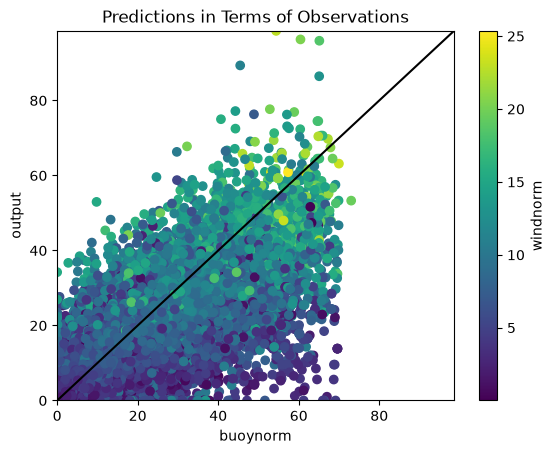

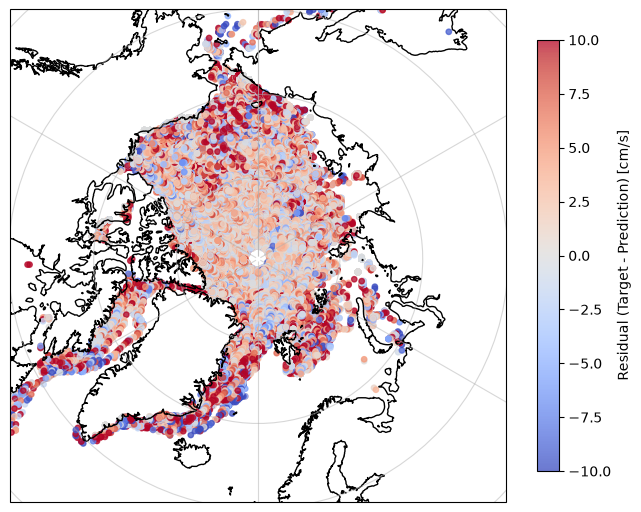

In [17]:

rmse=getRMSE(testdata['buoynorm'].values, testdata['output'].values)
print('Rmse: ', rmse)
PredAgainstTarget(testdata['buoynorm'], testdata['output'], testdata['windnorm'])
ResidualOnTheMap(testdata,'output', 'buoynorm')